In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [10]:
raw_data_path = Path("../data/raw/loan_approval_dataset.csv")
curated_data_path = Path("../data/curated/cleaned_loan_data.csv")

curated_data_path.parent.mkdir(parents=True, exist_ok=True)

loan_df = pd.read_csv(raw_data_path)

In [11]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1   no_of_dependents           4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [12]:
# Change data type of loan_id
loan_df["loan_id"] = loan_df["loan_id"].astype(str)

In [13]:
# Change the values of all numeric columns of the dataframe upto 2 point decimal

pd.set_option("display.float_format", "{:.2f}".format)
loan_df.describe()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [14]:
loan_df.columns

Index(['loan_id', 'no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

In [15]:
loan_df.columns = loan_df.columns.str.strip()
print(loan_df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


In [16]:
for col in loan_df.select_dtypes(include="str"):
    loan_df[col] = loan_df[col].str.strip()

### Detect Outlier

In [17]:
loan_df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


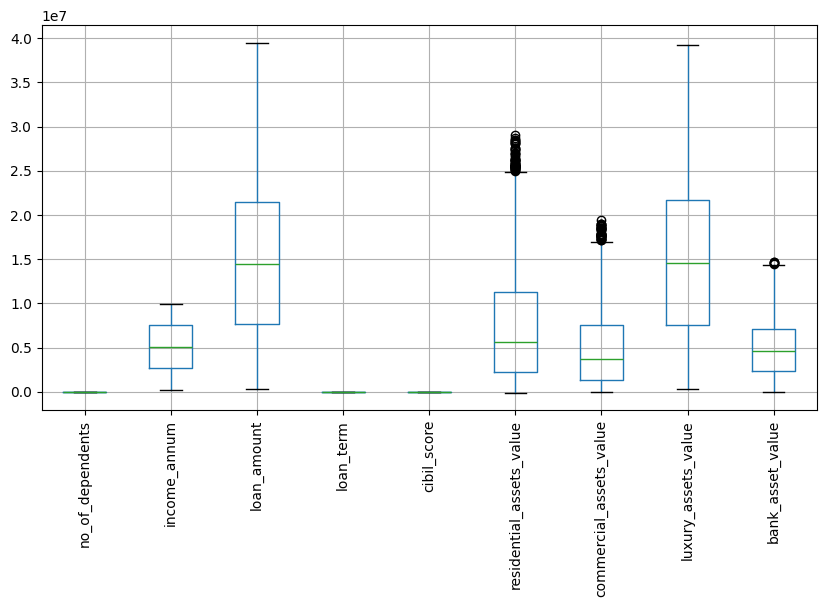

In [18]:
plt.figure(figsize=(10, 5))
loan_df.boxplot()
plt.xticks(rotation=90)
plt.show()

##### For mortgage underwriting, very large asset values are often legitimate.

### Feature Engineering

In [19]:
new_df = loan_df.copy()
new_df["loan_income_ratio"] = new_df["loan_amount"] / new_df["income_annum"]

asset_cols = ["residential_assets_value", "commercial_assets_value", "luxury_assets_value", "bank_asset_value"]

new_df["total_assets"] = new_df[asset_cols].sum(axis=1)
new_df["asset_coverage_ratio"] = new_df["total_assets"] / new_df["loan_amount"]
new_df["net_worth"] = new_df["total_assets"] - new_df["loan_amount"]

### Encoding

In [20]:
new_df["education"] = new_df["education"].map({"Not Graduate": 0, "Graduate": 1})

new_df["self_employed"] = new_df["self_employed"].map({"No": 0, "Yes": 1})

new_df["loan_status"] = new_df["loan_status"].map({"Rejected": 0, "Approved": 1})

In [22]:
new_df = new_df.drop(columns=["loan_id"])

In [23]:
new_df.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_income_ratio,total_assets,asset_coverage_ratio,net_worth
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,3.11,50700000,1.70,20800000
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,2.98,17000000,1.39,4800000
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,3.26,57700000,1.94,28000000
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,3.74,52700000,1.72,22000000
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,2.47,55000000,2.27,30800000


In [24]:
new_df.isnull().sum()

no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
loan_income_ratio           0
total_assets                0
asset_coverage_ratio        0
net_worth                   0
dtype: int64

In [26]:
new_df.duplicated().sum()

np.int64(0)

In [27]:
new_df.to_csv(curated_data_path, index=False)

print(f"Cleaned data saved to: {curated_data_path}")
print(new_df.shape)
new_df.head()

Cleaned data saved to: ../data/curated/cleaned_loan_data.csv
(4269, 16)


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_income_ratio,total_assets,asset_coverage_ratio,net_worth
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,3.11,50700000,1.70,20800000
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,2.98,17000000,1.39,4800000
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,3.26,57700000,1.94,28000000
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,3.74,52700000,1.72,22000000
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,2.47,55000000,2.27,30800000
